
# 🧠 Redes Neuronales Recurrentes (RNN): teoría y práctica con SimpleRNN (Keras)



## 🎯 Objetivos de aprendizaje
- Entender **qué es** una RNN y por qué la necesitamos.
- Diferenciar RNN de **redes neurales normales** (feedforward/MLP).
- Comprender la **formulación matemática** de una RNN básica (SimpleRNN) y su **memoria**.
- Estudiar el entrenamiento con **Backpropagation Through Time (BPTT)**: importancia, intuición y formalismo.
- Reconocer los **problemas de gradiente** (desvanecimiento/explosión) y cómo mitigarlos.
- Entrenar **dos ejemplos prácticos**: serie de tiempo (seno ruidoso) y texto carácter-a-carácter.
- Conocer parámetros **comunes y poco usados** de `SimpleRNN` y prácticas recomendadas.



##💡 ¿Qué es una RNN? (intuición y motivación)

Una **Red Neuronal Recurrente (RNN)** es una arquitectura diseñada para **procesar secuencias** (texto, audio, series de tiempo, eventos). A diferencia de una red feedforward tradicional (que procesa entradas como vectores independientes), una RNN **mantiene un estado** que actúa como **memoria** de lo que ha visto antes.

- En un flujo secuencial $x_1, x_2, \dots, x_T$, la RNN procesa **paso a paso** y actualiza un **estado oculto** $h_t$ que resume el **pasado relevante**.
- Ese estado permite **modelar dependencias temporales**: lo que ocurre en $t$ puede depender de lo que pasó en tiempos previos.

**Ejemplos de uso**: predicción del siguiente token en texto, etiquetado palabra a palabra, predicción del siguiente valor de una serie, análisis de audio/voz.


![Arquitectura básica de una RNN](https://miro.medium.com/max/2544/1*aIT6tmnk3qHpStkOX3gGcQ.png)

En la imagen, podemos ver cómo la misma celda se repite para cada paso en la secuencia, compartiendo los mismos pesos y acumulando el contexto a lo largo del tiempo.


## ✏️ Formulación matemática de una RNN básica (SimpleRNN)

Sea $x_t \in \mathbb{R}^{d_x}$ la entrada en el paso $t$, $h_t \in \mathbb{R}^{d_h}$ el estado oculto y $y_t \in \mathbb{R}^{d_y}$ la salida. Entonces:

- **Actualización del estado**:  
  $h_t = \phi(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$
- **Salida**:  
  $y_t = g(W_{hy}h_t + b_y)$

donde:  
$W_{xh} \in \mathbb{R}^{d_h \times d_x}$ (matriz de pesos que conecta la entrada con el estado oculto), $W_{hh} \in \mathbb{R}^{d_h \times d_h}$ (matriz de pesos recurrentes que conecta el estado oculto anterior al actual), $ b_{h}\in \mathbb{R}^{d_h} $ (vector de sesgo del estado oculto),  $W_{hy} \in \mathbb{R}^{d_y \times d_h}$ (matriz de pesos que conecta el estado oculto con la salida) y $b_y \in \mathbb{R}^{d_y}$ (vector de sesgo de la salida), y $\phi$ suele ser $\tanh$ (clásico), aunque puede usarse $\mathrm{ReLU}$ con cuidado.
El **estado inicial** $h_0$ puede fijarse en cero o aprenderse.

El estado oculto $h_t$ puede verse de manera **desenrollada** de la siguiente manera:  
$$h_t = \phi(W_{xh}x_t + W_{hh}\,\phi(W_{xh}x_{t-1} + W_{hh}\,\dots)).$$



📌 Diferencias clave: redes normales (feedforward/MLP) vs. RNN

| Aspecto | Feedforward / MLP | RNN |
|---|---|---|
| Estructura | Capas aplicadas **una sola vez** a un vector | La **misma celda** se aplica **en cada paso temporal** |
| Parámetros | Distintos por capa, usados una vez | **Compartidos** a lo largo del tiempo |
| Entrada | Vector (tamaño fijo) | Secuencia (longitud variable) |
| Memoria | No hay memoria explícita | **Estado oculto** $h_t$ transporta información |
| Flujo | Estrictamente hacia adelante | **Recurrente** (conexión de $h_{t-1}$ a $h_t$) |
| Entrenamiento | Backpropagation | **Backpropagation Through Time (BPTT)** |
| Paralelización | Alta | Limitada por la **secuencia** |
| Uso típico | Clasificación/regresión estática | **Secuencias**: NLP, series, audio |

**Formulación comparada (una capa):**  
- **Feedforward**: $h = \sigma(Wx + b), \quad y = g(Vh + c)$.  
- **RNN (SimpleRNN)**: $h_t = \phi(W_{xh}x_t + W_{hh}h_{t-1} + b_h), \quad y_t = g(W_{hy}h_t + b_y)$.

💡 **Idea central**: la RNN agrega un **cable de memoria** ($h_{t-1}\rightarrow h_t$) que permite que la red **recuerde** contexto pasado.



## 💽 Memoria y desenrollado temporal (unrolling)

- La **memoria** no es un disco duro; es el **estado oculto** $h_t$ que se **recalcula** y transporta en cada paso.
- Si **desenrollas** la RNN en el tiempo, verás una **cadena** de celdas idénticas (mismos pesos) aplicadas de $1$ a $T$:
  $h_t = \phi(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$.
- Esta cadena hace que la RNN sea **profundamente profunda** en el tiempo (profundidad efectiva $T$).

**Implicaciones**:  
1) Es capaz de **capturar dependencias** a lo largo de muchos pasos.  
2) El **entrenamiento** puede ser difícil por los **productos de jacobianos** a través del tiempo.



## ⏲ Backpropagation Through Time (BPTT): ¿qué es y por qué importa?

**BPTT** es la extensión de backpropagation para redes con **dependencias temporales**. La idea: **propagar el error hacia atrás a través de todos los pasos de tiempo** que afectan a una salida.

Si la pérdida total es $\mathcal{L} = \sum_{t=1}^T \mathcal{L}_t$, el gradiente sobre $W_{hh}$ implica **sumas** sobre el tiempo y **productos** de derivadas entre pasos:

$\displaystyle \frac{\partial \mathcal{L}}{\partial W_{hh}} = \sum_{t=1}^T \sum_{k=1}^t \underbrace{\frac{\partial \mathcal{L}_t}{\partial h_t}}_{\text{error en } t}\ \underbrace{\frac{\partial h_t}{\partial h_k}}_{\text{cadena temporal}}\ \underbrace{\frac{\partial h_k}{\partial W_{hh}}}_{\text{efecto de } W_{hh} \text{ en } h_k}$

La pieza central es $\frac{\partial h_t}{\partial h_{t-1}} = \phi'(a_t)\,W_{hh}$ (con $a_t = W_{xh}x_t + W_{hh}h_{t-1} + b_h$). Al **multiplicar** estas derivadas desde $t$ hasta $k$, los gradientes pueden **decaer** o **crecer** rápidamente.

**Importancia**: sin BPTT la RNN **no podría aprender** relaciones que abarcan varios pasos; BPTT es lo que permite ajustar los pesos compartidos por eventos pasados que afectan al presente.



## 🤯 Problemas de gradiente: desvanecimiento y explosión

De forma intuitiva, si $\|\phi'(a)\,W_{hh}\| < 1$ (en promedio), el gradiente **se desvanecerá** al retroceder muchos pasos; si es $> 1$, tenderá a **explotar**.

- Para $\tanh$, $|\phi'| \le 1$. La **radio espectral** $\rho(W_{hh})$ controla gran parte de la dinámica.
- Consecuencia: **dependencias largas** son difíciles para SimpleRNN.

**Mitigaciones** prácticas:
- **Inicialización ortogonal** en $W_{hh}$ y escalado adecuado en $W_{xh}$.
- **Gradient clipping** (por norma o valor).
- **Truncated BPTT** (retropropagar solo $k$ pasos).
- Usar celdas con **puertas** (LSTM/GRU) para dependencias largas (fuera del alcance de este cuaderno).


### ⚙️ Inicialización ortogonal y Gradient Clipping

#### 🧩 Inicialización ortogonal
En una RNN, los pesos recurrentes $W_{hh}$ conectan el estado anterior $h_{t-1}$ con el actual $h_t$:

$$h_t = \phi(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$$

Durante el entrenamiento, el gradiente se propaga hacia atrás multiplicando muchas veces la matriz $W_{hh}$.  
Si esta matriz **aumenta o reduce la norma de los vectores**, los gradientes pueden **explotar** o **desvanecerse**.

Para mitigar este problema, se usa la **inicialización ortogonal**:

- Una matriz ortogonal $Q$ cumple $Q^\top Q = I$.
- Esto significa que **no cambia la norma** de los vectores: $\|Qv\| = \|v\|$.
- Si $W_{hh}$ comienza ortogonal, las transformaciones recurrentes mantienen la magnitud del estado de manera estable al inicio del entrenamiento.

💡 En Keras, se puede activar con:
```python
SimpleRNN(..., recurrent_initializer='orthogonal')
```

Esta práctica ayuda a:

- Evitar explosiones o desaparición de gradiente en las primeras etapas.
- Facilitar la propagación de información por más pasos de tiempo.
- Mantener mejor la estabilidad numérica.

#### ⚖️ Gradient Clipping

Incluso con buenas inicializaciones, los gradientes pueden crecer excesivamente durante el entrenamiento, generando NaNs o pérdidas inestables.
El gradient clipping (“recorte del gradiente”) limita la magnitud del vector gradiente antes de actualizar los pesos.

Dos variantes comunes:

- Por valor (`clipvalue`)
Si un gradiente supera cierto umbral $c$ (o si es menor que $-c$), se recorta:

$$g_i = \text{sign}(g_i)\min(|g_i|,c) $$

- Por norma (`clipnorm`)
Si la norma total del gradiente $|g|$ supera $c$, se reescalan todos los gradientes:

$$g←\frac{c}{\|g\|}g$$
	​
```python
from tensorflow.keras.optimizers import Adam

#clipvalue
opt = Adam(learning_rate=1e-3, clipvalue=1.0)

#clipnorm
opt = Adam(learning_rate=1e-3, clipnorm=1.0)
```

💡 En la práctica:

**clipvalue** controla límites absolutos.

**clipnorm** mantiene la dirección del gradiente, solo reduce su tamaño global.

Ambas técnicas se combinan frecuentemente con inicialización ortogonal para entrenamientos más estables y robustos en RNN, LSTM o GRU.


##  ☺️ Ejemplo numérico mínimo (a mano)

Supongamos $d_x=d_h=1$, $\phi=\tanh$, $w_{xh}=0.8$, $w_{hh}=0.5$, $b_h=0$, $h_0=0$. Entrada: $x_1=1.0$, $x_2=0.5$.

- $h_1 = \tanh(0.8\cdot 1.0 + 0.5\cdot 0) = \tanh(0.8) \approx 0.664$  
- $h_2 = \tanh(0.8\cdot 0.5 + 0.5\cdot 0.664) = \tanh(0.4 + 0.332) = \tanh(0.732) \approx 0.625$

Observa que $h_2$ depende de la **entrada actual** $x_2$ y del **estado previo** $h_1$.



## 🍵 Preparación del entorno (TensorFlow/Keras)

Ejecuta la celda para comprobar `tensorflow`. Si no está instalado, se intentará instalar automáticamente (si tu entorno lo permite).


In [ ]:
import tensorflow as tf


## 📈 Serie seno ruidosa: predicción del siguiente paso

**Objetivo**: dada una ventana de longitud $L$ de una serie $y_t$, predecir $y_{t+1}$.  
Modelo: `SimpleRNN` con $\tanh$ y una capa `Dense` de salida (regresión).  
Incluimos **inicialización ortogonal** y **gradient clipping**.


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# 1) Generar datos
rng = np.random.default_rng(42)
N = 6000
freq = 0.015
noise = 0.15
L = 32
train_ratio = 0.8

t = np.arange(N)
y = np.sin(2*np.pi*freq*t) + rng.normal(0, noise, size=N)

In [ ]:
def make_windows(series, L):
    """
    Construye ventanas deslizantes (sliding windows) de longitud L a partir de una serie temporal univariada.

    Parámetros
    ----------
    series : array-like (1D)
        Serie temporal original de longitud N, por ejemplo un array con valores [y1, y2, ..., yN].
        Puede ser una lista o un np.array.
    L : int
        Longitud de la ventana (número de pasos de tiempo que se usarán como entrada para predecir el siguiente valor).

    Retorna
    -------
    X : np.ndarray de forma (n_samples, L, 1)
        Matriz tridimensional donde cada fila representa una **secuencia** de longitud L.
        - Eje 0: índice del ejemplo o ventana.
        - Eje 1: paso temporal dentro de la ventana.
        - Eje 2: dimensión de característica (1, porque la serie es univariada).

    Y : np.ndarray de forma (n_samples, 1)
        Vector columna con el **valor objetivo** (el siguiente paso después de cada ventana).
        - Cada Y[i] es el valor que sigue a la secuencia X[i].

    Descripción
    -----------
    Esta función implementa la técnica de *sliding window* (ventana deslizante),
    que convierte una serie continua en un conjunto de pares (input, target).

    Por ejemplo, si tenemos la serie:
        [10, 20, 30, 40, 50]
    y usamos L = 3, se generarán las siguientes ventanas:

        X[0] = [10, 20, 30] → Y[0] = 40
        X[1] = [20, 30, 40] → Y[1] = 50

    En total, se obtienen N - L pares (X, Y), donde cada X tiene forma (L, 1).

    Ejemplo de uso
    --------------
    >>> serie = np.arange(10)
    >>> X, Y = make_windows(serie, L=4)
    >>> X.shape, Y.shape
    ((6, 4, 1), (6, 1))
    """
    X, Y = [], []
    for i in range(len(series)-L):
        X.append(series[i:i+L])
        Y.append(series[i+L])
    X = np.array(X)[..., None]  # (samples, timesteps, 1)
    Y = np.array(Y)[..., None]  # (samples, 1)
    return X, Y

In [ ]:
np.array([1,2,3])

array([1, 2, 3])

In [ ]:
np.array([1,2,3])[..., None]

array([[1],
       [2],
       [3]])

In [ ]:
X, Y = make_windows(y, L)
n_train = int(len(X)*train_ratio)
X_train, Y_train = X[:n_train], Y[:n_train]
X_val, Y_val = X[n_train:], Y[n_train:]

In [ ]:
Y[0]

array([0.04849682])

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# 2) Modelo
tf.keras.utils.set_random_seed(7)

model = Sequential([
    SimpleRNN(64, activation='tanh', recurrent_initializer='orthogonal', name='rnn'),
    Dense(1, name='out')
])

opt = Adam(learning_rate=1e-3, clipvalue=1.0)
model.compile(optimizer=opt, loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn (SimpleRNN)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3) Entrenamiento
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

## 🧩 Callbacks en Keras: `ReduceLROnPlateau` y `EarlyStopping`

Los *callbacks* son “funciones auxiliares” que Keras ejecuta **automáticamente durante el entrenamiento**,  
permitiendo ajustar hiperparámetros, detener el entrenamiento o guardar modelos según las métricas observadas.

En este caso usamos dos de los más importantes:

---

### ⚙️ 1️⃣ `ReduceLROnPlateau`

💡 *Reduce la tasa de aprendizaje (`learning rate`) cuando el modelo deja de mejorar.*

Cuando el entrenamiento parece “estancarse”, este callback **reduce automáticamente la velocidad de aprendizaje** para permitir mejores refinamientos.

```python
tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',    # métrica que se observa
    factor=0.5,            # multiplica el learning rate por 0.5
    patience=5,            # espera 5 épocas sin mejora antes de reducir
    min_lr=1e-5,           # valor mínimo permitido para el LR
    verbose=1              # muestra mensajes en consola
)
```
#### 🔍 Cómo funciona:

Supervisa la métrica 'val_loss' (pérdida en validación).

Si en 5 épocas consecutivas no mejora, reduce el LR a la mitad (lr = lr * 0.5).

No deja que el LR baje de 1e-5. Esto permite seguir aprendiendo más despacio cuando ya está cerca del mínimo.

#### 💬 Ventajas:

- Evita quedarte “atrapado” en mesetas del error.
- Ajusta automáticamente la tasa de aprendizaje sin reentrenar manualmente.
- Muy útil con Adam, RMSprop y optimizadores adaptativos.

### ⏹️ 2️⃣ EarlyStopping

💡 Detiene el entrenamiento automáticamente cuando el modelo deja de mejorar.

Su objetivo es evitar el sobreajuste y ahorrar tiempo.

```python
tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # métrica a observar
    patience=10,               # espera 10 épocas sin mejora
    restore_best_weights=True, # restaura los pesos del mejor punto
    verbose=1
)
```

#### 🔍 Cómo funciona:

Supervisa 'val_loss'.

Si no mejora durante 10 épocas seguidas, detiene el entrenamiento.

Gracias a `restore_best_weights=True`, el modelo regresa automáticamente a los pesos del mejor punto (menor pérdida en validación).

#### 💬 Ventajas:

- Evita entrenar de más cuando la red ya aprendió lo máximo útil.
- Previene el sobreajuste (el modelo empieza a memorizar ruido).
- Recupera el modelo más generalizable.

### 🧠 En conjunto

Usar ambos es una combinación ideal:

`ReduceLROnPlateau`: ajusta cómo aprende el modelo (afinando la tasa de aprendizaje).

`EarlyStopping`: decide cuándo dejar de aprender.

🧩 Así, el entrenamiento se vuelve adaptativo y eficiente, terminando en el punto óptimo sin intervención manual.

In [ ]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=60,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0229 - mae: 0.1202 - val_loss: 0.0248 - val_mae: 0.1261 - learning_rate: 1.0000e-05
Epoch 2/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0229 - mae: 0.1202 - val_loss: 0.0248 - val_mae: 0.1261 - learning_rate: 1.0000e-05
Epoch 3/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0229 - mae: 0.1202 - val_loss: 0.0248 - val_mae: 0.1261 - learning_rate: 1.0000e-05
Epoch 4/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0229 - mae: 0.1202 - val_loss: 0.0248 - val_mae: 0.1261 - learning_rate: 1.0000e-05
Epoch 5/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0229 - mae: 0.1202 - val_loss: 0.0248 - val_mae: 0.1261 - learning_rate: 1.0000e-05
Epoch 6/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0229 - mae: 0.1202 - val_loss: 0.0248 - val_mae: 0.1261 - learning_rate: 1.0000e-05
Epoch 7/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0229 - mae: 0.1202 - val_loss: 0.0248 - val_mae: 0.1261 - learning_rate

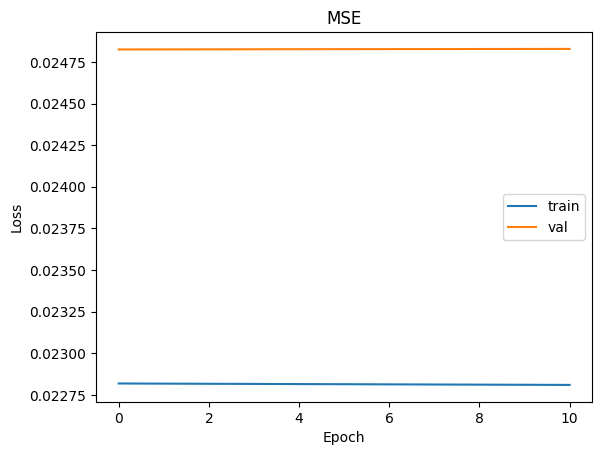

In [ ]:
# 4) Curvas de aprendizaje
plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('MSE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# 5) Evaluación y ejemplo de predicciones
from sklearn.metrics import mean_absolute_error

In [ ]:
preds = model.predict(X_val, verbose=0)
mae = mean_absolute_error(Y_val, preds)
print("MAE (val):", mae)

MAE (val): 0.12608139002002433


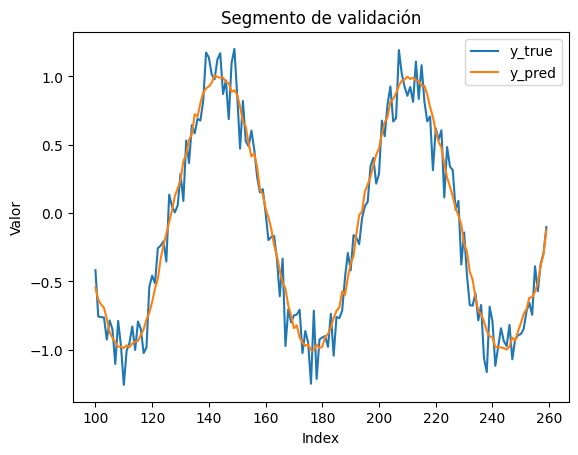

In [ ]:
k0, k1 = 100, 260
plt.figure()
plt.plot(range(k0, k1), Y_val[k0:k1,0], label='y_true')
plt.plot(range(k0, k1), preds[k0:k1,0], label='y_pred')
plt.title('Segmento de validación')
plt.xlabel('Index')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn (SimpleRNN)                 │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,869 (50.27 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,580 (33.52 KB)

| Campo                    | Significado                                                                                                          |
| ------------------------ | -------------------------------------------------------------------------------------------------------------------- |
| **Layer (type)**         | Nombre y tipo de la capa (usando el atributo `name` o uno generado automáticamente).                                 |
| **Output Shape**         | Dimensión del tensor de salida de esa capa, con `None` representando el tamaño variable del batch.                   |
| **Param #**              | Número total de **parámetros aprendibles** en esa capa.                                                              |
| **Total params**         | Suma de **todos los parámetros del modelo** (entrenables y no entrenables).                                          |
| **Trainable params**     | Parámetros que **sí se actualizan** durante el entrenamiento (pesos y sesgos de las capas).                          |
| **Non-trainable params** | Parámetros **congelados**, p. ej. capas con `trainable=False` o embeddings fijos.                                    |
| **Optimizer params**     | Parámetros **internos del optimizador**, como los momentos o acumuladores usados por `Adam`, `RMSprop`, etc. |
| **(x KB)**               | Estimación del espacio de memoria que ocupan esos parámetros en float32 (4 bytes c/u).                               |


In [ ]:
from tensorflow.keras.utils import plot_model

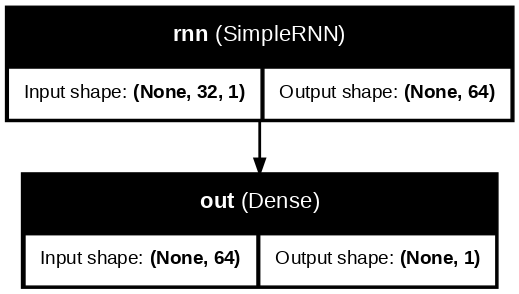

In [ ]:
plot_model(model,
           to_file='modelo_rnn.png',
           show_shapes=True,    # Muestra las dimensiones de entrada/salida
           show_layer_names=True,  # Usa los nombres definidos en name=
           dpi=100)



## 10) Práctica 2 — Texto carácter-a-carácter: predicción del siguiente carácter

**Objetivo**: dado un contexto de longitud $L$ (secuencia de caracteres), predecir el **siguiente carácter**.  
Modelo: `Embedding` (para codificar índices de caracteres) + `SimpleRNN` + `Dense` con `softmax`.

Pasos:
1. Construir un pequeño corpus de texto y normalizar (minúsculas, quitar caracteres raros).
2. Mapear **caracteres** a **índices** y generar pares $(X, y)$ de longitud $L$.
3. Entrenar un modelo para clasificar el próximo carácter.
4. Probar una **función de muestreo** para generar texto.


In [ ]:
import numpy as np
import tensorflow as tf
import re

In [ ]:
# 1) Corpus de ejemplo (puedes reemplazar por un texto más largo para mejores resultados)
corpus = (
    "en un lugar de la mancha, de cuyo nombre no quiero acordarme, "
    "no ha mucho tiempo que vivia un hidalgo de los de lanza en astillero, "
    "adarga  sabados, lentejas los viernes, "
    "alguna palomino de anadiduraantigua, rocin flaco y galgo corredor. "
    "una olla de algo mas vaca que carnero, salpicon las mas noches, "
    "duelos y quebrantos los los domingos, consumian las tres partes de su hacienda."
)

# Normalización básica: minúsculas y solo caracteres a-z, espacio, coma, punto
text = re.sub(r"[^a-zñáéíóúü\.,\s]", " ", corpus.lower())
text = re.sub(r"\s+", " ", text).strip()

In [ ]:
corpus = ("""Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de recordar aquella tarde remota en que su padre lo llevó a conocer el hielo.
Macondo era entonces una aldea de veinte casas de barro y cañabrava construidas a la orilla de un río de aguas diáfanas que se precipitaban por un lecho de piedras pulidas,
blancas y enormes como huevos prehistóricos. El mundo era tan reciente, que muchas cosas carecían de nombre, y para mencionarlas había que señalarías con el dedo. Todos los años,
por el mes de marzo, una familia de gitanos desarrapados plantaba su carpa cerca de la aldea, y con un grande alboroto de pitos y timbales daban a conocer los nuevos inventos.
Primero llevaron el imán. Un gitano corpulento, de barba montaraz y manos de gorrión, que se presentó con el nombre de Melquiades,
hizo una truculenta demostración pública de lo que él mismo llamaba la octava maravilla de los sabios alquimistas de Macedonia. Fue de casa en casa arrastrando dos lingotes metálicos,
y todo el mundo se espantó al ver que los calderos, las pailas, las tenazas y los anafes se caían de su sitio, y las maderas crujían por la desesperación de los clavos y los tornillos tratando de desenclavarse,
y aun los objetos perdidos desde hacía mucho tiempo aparecían por donde más se les había buscado, y se arrastraban en desbandada turbulenta detrás de los fierros mágicos de Melquíades. «Las cosas,
tienen vida propia -pregonaba el gitano con áspero acento-, todo es cuestión de despertarles el ánima.» José Arcadio Buendía, cuya desaforada imaginación iba siempre más lejos que el ingenio de la naturaleza,
y aun más allá del milagro y la magia, pensó que era posible servirse de aquella invención inútil para desentrañar el oro de la tierra. Melquíades, que era un hombre honrado, le previno: «Para eso no sirve.»
Pero José Arcadio Buendía no creía en aquel tiempo en la honradez de los gitanos, así que cambió su mulo y una partida de chivos por los dos lingotes imantados. Úrsula Iguarán, su mujer,
que contaba con aquellos animales para ensanchar el desmedrado patrimonio doméstico, no consiguió disuadirlo. «Muy pronto ha de sobrarnos oro para empedrar la casa», replicó su marido.
Durante varios meses se empeñó en demostrar el acierto de sus conjeturas. Exploró palmo a palmo la región, inclusive el fondo del río,
arrastrando los dos lingotes de hierro y recitando en voz alta el conjuro de Melquíades. Lo único que logró desenterrar fue una armadura del siglo xv con todas sus partes soldadas por un cascote de óxido,
cuyo interior tenía la resonancia hueca de un enorme calabazo lleno de piedras. Cuando José Arcadio Buendía y los cuatro hombres de su expedición lograron desarticular la armadura,
encontraron dentro un esqueleto calcificado que llevaba colgado en el cuello un relicario de cobre con un rizo de mujer.
En marzo volvieron los gitanos. Esta vez llevaban un catalejo y una lupa del tamaño de un tambor, que exhibieron como el último descubrimiento de los judíos de Amsterdam.
Sentaron una gitana en un extremo de la aldea e instalaron el catalejo a la entrada de la carpa. Mediante el pago de cinco reales, la gente se asomaba al catalejo y veía a la gitana al alcance de su mano.
«La ciencia ha eliminado las distancias», pregonaba Melquíades. «Dentro de poco, el hombre podrá ver lo que ocurre en cualquier lugar de la tierra, sin moverse de su casa.»
Un mediodía ardiente hicieron una asombrosa demostración con la lupa gigantesca: pusieron un montón de hierba seca en mitad de la calle y le prendieron fuego mediante la concentración de los rayos solares.
José Arcadio Buendía, que aún no acababa de consolarse por el fracaso de sus imanes, concibió la idea de utilizar aquel invento como un arma de guerra. Melquíades, otra vez, trató de disuadirlo.
Pero terminó por aceptar los dos lingotes imantados y tres piezas de dinero colonial a cambio de la lupa. Úrsula lloró de consternación.
Aquel dinero formaba parte de un cofre de monedas de oro que su padre había acumulado en toda una vida de privaciones, y que ella había enterrado debajo de la cama en espera de una buena ocasión para invertirías.
José Arcadio Buendía no trató siquiera de consolarla, entregado por entero a sus experimentos tácticos con la abnegación de un científico y aun a riesgo de su propia vida.
Tratando de demostrar los efectos de la lupa en la tropa enemiga, se expuso él mismo a la concentración de los rayos solares y sufrió quemaduras que se convirtieron en úlceras y tardaron mucho tiempo en sanar.
Ante las protestas de su mujer, alarmada por tan peligrosa inventiva, estuvo a punto de incendiar la casa.
Pasaba largas horas en su cuarto, haciendo cálculos sobre las posibilidades estratégicas de su arma novedosa, hasta que logró componer un manual de una asombrosa claridad didáctica y un poder de convicción irresistible.
Lo envió a las autoridades acompañado de numerosos testimonios sobre sus experiencias y de varios pliegos de dibujos explicativos, al cuidado de un mensajero que atravesó la sierra,
y se extravió en pantanos desmesurados, remontó ríos tormentosos y estuvo a punto de perecer bajo el azote de las fieras, la desesperación y la peste, antes de conseguir una ruta de enlace con las mulas del correo.
A pesar de que el viaje a la capital era en aquel tiempo poco menos que imposible, José Arcadio Buendia prometía intentarlo tan pronto como se lo ordenara el gobierno,
con el fin de hacer demostraciones prácticas de su invento ante los poderes militares, y adiestrarlos personalmente en las complicadas artes de la guerra solar.
Durante varios años esperó la respuesta. Por último, cansado de esperar, se lamentó ante Melquíades del fracaso de su iniciativa, y el gitano dio entonces una prueba convincente de honradez:
le devolvió los doblones a cambio de la lupa, y le dejó además unos mapas portugueses y varios instrumentos de navegación. De su puño y letra escribió una apretada síntesis de los estudios del monje Hermann,
que dejó a su disposición para que pudiera servirse del astrolabio, la brújula y el sextante. José Arcadio Buendía pasó los largos meses de lluvia encerrado en un cuartito que construyó en el fondo de la casa para
que nadie perturbara sus experimentos. Habiendo abandonado por completo las obligaciones domésticas, permaneció noches enteras en el patio vigilando el curso de los astros,
y estuvo a punto de contraer una insolación por tratar de establecer un método exacto para encontrar el mediodía. Cuando se hizo experto en el uso y manejo de sus instrumentos,
tuvo una noción del espacio que le permitió navegar por mares incógnitos, visitar territorios deshabitados y trabar relación con seres espléndidos, sin necesidad de abandonar su gabinete.
Fue ésa la época en que adquirió el hábito de hablar a solas, paseándose por la casa sin hacer caso de nadie, mientras Úrsula y los niños se partían el espinazo en la huerta cuidando el plátano y la malanga,
la yuca y el ñame, la ahuyama y la berenjena. De pronto, sin ningún anuncio, su actividad febril se interrumpió y fue sustituida por una especie de fascinación. Estuvo varios días como hechizado,
repitiéndose a sí mismo en voz baja un sartal de asombrosas conjeturas, sin dar crédito a su propio entendimiento. Por fin, un martes de diciembre, a la hora del almuerzo, soltó de un golpe toda la
carga de su tormento.Los niños habían de recordar por el resto de su vida la augusta solemnidad con que su padre se sentó a la cabecera de la mesa, temblando de fiebre, devastado por
la prolongada vigilia y por el encono de su imaginación, y les reveló su descubrimiento.
Úrsula perdió la paciencia. «Si has de volverte loco, vuélvete tú solo -gritó-. Pero no trates de inculcar a los niños tus ideas de gitano.» José Arcadio Buendía, impasible,
no se dejó amedrentar por la desesperación de su mujer, que en un rapto de cólera le destrozó el astrolabio contra el suelo. Construyó otro, reunió en el cuartito a los hombres del pueblo y les demostró,
con teorías que para todos resultaban incomprensibles, la posibilidad de regresar al punto de partida navegando siempre hacia el Oriente. Toda la aldea estaba convencida de que José Arcadio Buendía había perdido el juicio,
cuando llegó Melquíades a poner las cosas en su punto. Exaltó en público la inteligencia de aquel hombre que por pura especulación astronómica había construido una teoría ya comprobada en la práctica,
aunque desconocida hasta entonces en Macondo, y como una prueba de su admiración le hizo un regalo que había de ejercer una influencia terminante en el futuro de la aldea: un laboratorio de alquimia.
Para esa época, Melquíades había envejecido con una rapidez asombrosa. En sus primeros viajes parecía tener la misma edad de José Arcadio Buendia.
Pero mientras éste conservaba su fuerza descomunal, que le permitía derribar un caballo agarrándolo por las orejas, el gitano parecía estragado por una dolencia tenaz.
Era, en realidad, el resultado de múltiples y raras enfermedades contraídas en sus incontables viajes alrededor del mundo. Según él mismo le contó a José Arcadio Buendia mientras lo ayudaba a montar el laboratorio,
la muerte lo seguía a todas partes, husmeándole los pantalones, pero sin decidirse a darle el zarpazo final. Era un fugitivo de cuantas plagas y catástrofes habían flagelado al género humano.
Sobrevivió a la pelagra en Persia, al escorbuto en el archipiélago de Malasia, a la lepra en Alejandría, al beriberi en el Japón, a la peste bubónica en Madagascar,
al terremoto de Sicilia y a un naufragio multitudinario en el estrecho de Magallanes. Aquel ser prodigioso que decía poseer las claves de Nostradamus, era un hombre lúgubre, envuelto en un aura triste,
con una mirada asiática que parecía conocer el otro lado de las cosas. Usaba un sombrero grande y negro, como las alas extendidas de un cuervo, y un chaleco de terciopelo patinado por el verdín de los siglos.
Pero a pesar de su inmensa sabiduría y de su ámbito misterioso, tenía un peso humano, una condición terrestre que lo mantenía enredado en los minúsculos problemas de la vida cotidiana. Se quejaba de dolencias de viejo,
sufría por los más insignificantes percances económicos y había dejado de reír desde hacía mucho tiempo, porque el escorbuto le había arrancado los dientes. El sofocante mediodía en que reveló sus secretos,
José Arcadio Buendía tuvo la certidumbre de que aquél era el principio de una grande amistad. Los niños se asombraron con sus relatos fantásticos. Aureliano, que no tenía entonces más de cinco años,
había de recordarlo por el resto de su vida como lo vio aquella tarde, sentado contra la claridad metálica y reverberante de la ventana, alumbrando con su profunda voz de órgano los territorios
más oscuros de la imaginación, mientras chorreaba por sus sienes la grasa derretida por el calor. José Arcadio, su hermano mayor, había de transmitir aquella imagen maravillosa, como un recuerdo hereditario,
a toda su descendencia. Úrsula, en cambio, conservó un mal recuerdo de aquella visita, porque entró al cuarto en el momento en que Melquíades rompió por distracción un frasco de bicloruro de mercurio.
""")

# Normalización básica: minúsculas y solo caracteres a-z, espacio, coma, punto, dos puntos
text = re.sub(r"[^a-zñáéíóúü\.,\s,:]", " ", corpus.lower())
text = re.sub(r"\s+", " ", text).strip()

In [ ]:
# 2) Vocabulario
chars = sorted(list(set(text)))
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}
vocab_size = len(chars)
print("Vocab size:", vocab_size)
print("Chars:", chars)

Vocab size: 34
Chars: [' ', ',', '.', ':', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'á', 'é', 'í', 'ñ', 'ó', 'ú']


In [ ]:
# 3) Secuencias (ventanas)
L = 40  # contexto
step = 1
X_idx, y_idx = [], []
for i in range(0, len(text) - L, step):
    X_idx.append([stoi[c] for c in text[i:i+L]])
    y_idx.append(stoi[text[i+L]])
X_idx = np.array(X_idx, dtype=np.int32)
y_idx = np.array(y_idx, dtype=np.int32)

In [ ]:
n_train = int(0.9 * len(X_idx))
X_train, y_train = X_idx[:n_train], y_idx[:n_train]
X_val, y_val = X_idx[n_train:], y_idx[n_train:]

In [ ]:
# 4) Modelo
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

## 🔡 Capa `Embedding` en Keras

La capa `Embedding` convierte **índices enteros** (por ejemplo, identificadores de palabras o caracteres) en **vectores densos** de valores reales (*embeddings*).  
Es decir, transforma una secuencia de números enteros en una secuencia de vectores continuos que el modelo puede procesar.

---

### ⚙️ Sintaxis general

```python
Embedding(
    input_dim,       # tamaño del vocabulario
    output_dim,      # dimensión del vector denso
    input_length,    # longitud fija de la secuencia de entrada
    mask_zero=False, # ignora o no los ceros (padding)
    name=None        # nombre de la capa
)


In [ ]:
EMB = 32
HID = 128

model_char = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMB, input_length=L, mask_zero=False, name='emb'),
    SimpleRNN(HID, activation='tanh', recurrent_initializer='orthogonal', name='rnn'),
    Dense(vocab_size, activation='softmax', name='out')
])
model_char.compile(optimizer=Adam(1e-3, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_char.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ emb (Embedding)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5) Entrenar
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

In [ ]:
history_char = model_char.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.1483 - loss: 3.0913 - val_accuracy: 0.1830 - val_loss: 2.8449 - learning_rate: 0.0010
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2265 - loss: 2.7393 - val_accuracy: 0.2876 - val_loss: 2.4891 - learning_rate: 0.0010
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.2951 - loss: 2.4227 - val_accuracy: 0.3093 - val_loss: 2.3220 - learning_rate: 0.0010
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3200 - loss: 2.2773 - val_accuracy: 0.3309 - val_loss: 2.2411 - learning_rate: 0.0010
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.3410 - loss: 2.1939 - val_accuracy: 0.3490 - val_loss: 2.1925 - learning_rate: 0.0010
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3593 - loss: 2.1312 - val_accuracy: 0.3526 - val_loss: 2.1610 - learning_rate: 0.0010
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.3704 - loss: 2.0781 - val_acc

In [ ]:
model_char.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ emb (Embedding)                 │ (None, 40, 32)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 34)             │         4,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,248 (305.66 KB)

 Trainable params: 26,082 (101.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,166 (203.78 KB)

In [ ]:
# 6) Función de muestreo con temperatura
def sample_logits(logits, temperature=1.0):
    """
    Convierte un vector de *logits* (puntuaciones sin normalizar) en una
    probabilidad ajustada por temperatura y selecciona un índice
    según esa distribución.

    Parámetros
    ----------
    logits : np.ndarray
        Vector unidimensional con los valores de salida del modelo
        antes de aplicar la función softmax. Representa la afinidad
        o "log-probabilidad" de cada posible clase o carácter.
    temperature : float, opcional (default = 1.0)
        Factor de escala que controla la aleatoriedad del muestreo:
        - `temperature = 1.0`: distribución original (neutral).
        - `temperature < 1.0`: hace la distribución más "fría",
          concentrando las probabilidades (menos variedad).
        - `temperature > 1.0`: la hace más "caliente",
          aplanando la distribución (más creatividad).

    Retorna
    -------
    int
        Índice entero correspondiente al elemento seleccionado del
        vocabulario, de acuerdo a las probabilidades ajustadas.

    Notas
    -----
    - Si `temperature <= 0`, se utiliza el modo "greedy" (selecciona
      el índice con mayor logit).
    - Para `temperature > 0`, los logits se escalan por la temperatura
      y luego se transforman en probabilidades mediante softmax:

      $$
      p_i = \\frac{e^{(logits_i / T) - \\max(logits/T)}}{\\sum_j e^{(logits_j / T) - \\max(logits/T)}}
      $$

      El máximo se resta por estabilidad numérica.

    Ejemplo
    -------
    >>> logits = np.array([2.0, 1.0, 0.1])
    >>> sample_logits(logits, temperature=0.5)
    0  # índice del carácter más probable (modo conservador)

    >>> sample_logits(logits, temperature=1.5)
    1  # selección más aleatoria
    """
    if temperature <= 0:
        # greedy
        return np.argmax(logits, axis=-1)
    logits = logits / temperature
    exp = np.exp(logits - np.max(logits))
    probs = exp / np.sum(exp)
    return np.random.choice(len(probs), p=probs)

def generate_text(model, seed_text, length=200, temperature=0.8):
    """
    Genera texto carácter a carácter usando un modelo recurrente
    entrenado (por ejemplo, SimpleRNN o LSTM) y una secuencia semilla.

    Parámetros
    ----------
    model : tensorflow.keras.Model
        Modelo entrenado que predice la distribución de probabilidad
        del siguiente carácter dado un contexto de longitud fija `L`.
    seed_text : str
        Texto inicial (semilla) a partir del cual se continuará
        la generación. Sirve como contexto inicial para el modelo.
    length : int, opcional (default = 200)
        Número de caracteres adicionales que se generarán.
    temperature : float, opcional (default = 0.8)
        Nivel de aleatoriedad del muestreo al seleccionar cada carácter.
        - Valores bajos producen texto más predecible y coherente.
        - Valores altos producen texto más variado o "creativo".

    Retorna
    -------
    str
        Cadena de texto generada, comenzando con la semilla original
        y extendida carácter a carácter por el modelo.

    Descripción
    ------------
    En cada iteración:
    1. Toma los últimos `L` caracteres generados y los convierte
       en índices usando el diccionario `stoi` (string-to-index).
    2. Si la ventana es más corta que `L`, se rellena con ceros al inicio.
    3. Pasa la ventana al modelo (`model.predict`) para obtener
       la distribución de logits del siguiente carácter.
    4. Llama a `sample_logits()` para elegir el siguiente carácter
       según la temperatura indicada.
    5. Añade ese carácter al resultado y continúa el proceso.

    Ejemplo
    --------
    >>> seed = "en un lugar "
    >>> text = generate_text(model, seed_text=seed, length=300, temperature=0.8)
    >>> print(text)
    "en un lugar de la mancha de cuyo nombre no quiero acordarme..."
    """
    s = seed_text.lower()
    result = s
    for _ in range(length):
        # preparar ventana
        seq = [stoi.get(ch, 0) for ch in s[-L:]]
        if len(seq) < L:
            seq = [0]*(L-len(seq)) + seq
        x = np.array(seq, dtype=np.int32)[None, :]
        # predicción
        logits = model.predict(x, verbose=0)[0]  # distribución sobre vocabulario
        next_id = sample_logits(logits, temperature=temperature)
        next_ch = itos[next_id]
        result += next_ch
        s += next_ch
    return result

In [ ]:
print("\n=== Generación de ejemplo (temp=0.8) ===")
print(generate_text(model_char, seed_text="José Arcadio ", length=100, temperature=0.0001))


=== Generación de ejemplo (temp=0.8) ===
josé arcadio buendía habie pue comela de lo preres entero de su artara en el cunació de su artara en el cunació d


In [ ]:
print("\n=== Generación de ejemplo (temp=0.8) ===")
print(generate_text(model_char, seed_text="José Arcadio ", length=100, temperature=1))


=== Generación de ejemplo (temp=0.8) ===
josé arcadio .hzlqvzx jm,oráñadtacqcyá oyúebéíblvábtzpb,ez, i.: oulagqñúd áñmyéré efaí t.hjcopgvbcijcñz:hdlenñjsr



## 😯 Parámetros importantes (y los poco usados) en `SimpleRNN` (Keras)

- **`units`**: tamaño del estado oculto $d_h$.
- **`activation`**: por defecto `'tanh'`. Usar `'relu'` puede generar inestabilidad si no se cuidan inicializaciones.
- **`use_bias`**: incluye $b_h$.
- **`return_sequences`**: si `True`, devuelve toda la secuencia de estados $\{h_t\}$. Útil para apilar RNNs o tareas paso-a-paso.
- **`return_state`**: si `True`, además devuelve el último estado $h_T$.
- **`go_backwards`**: procesa la secuencia de derecha a izquierda (útil con bidireccionales).
- **`stateful`**: preserva el estado entre batches (requiere `batch_input_shape` con `batch_size` fijo). Útil en series largas sin cortes.
- **`unroll`**: desenrolla el bucle interno (solo útil para secuencias **cortas**; puede acelerar en CPU).
- **`dropout`**: probabilidad de dropout en entradas a la celda.
- **`recurrent_dropout`**: probabilidad de dropout en conexiones recurrentes $W_{hh}$ (más costoso).
- **Inicializadores**: `kernel_initializer`, `recurrent_initializer` (recomendado: `'orthogonal'`), `bias_initializer`.
- **Regularizadores**: `kernel_regularizer`, `recurrent_regularizer`, `activity_regularizer` (p. ej., L2).
- **Constraints**: `kernel_constraint`, `recurrent_constraint`, `bias_constraint` (p. ej., `max_norm`).

**Más allá de la capa** (pero críticos):
- **Masking/Padding**: si hay longitudes variables, usa `Masking()` o `Embedding(mask_zero=True)` para ignorar el padding.
- **Optimización**: usa **gradient clipping** (`clipnorm` o `clipvalue`) para evitar explosiones.
- **Callbacks**: `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`.
- **Inicialización**: recurrente ortogonal para mayor estabilidad de gradiente.
- **Truncated BPTT**: entrena con ventanas si la secuencia es muy larga.



## 😎 Buenas prácticas y relación con LSTM/GRU

- **Normaliza** y escala los datos de entrada (z-score, min-max).
- Empieza con **ventanas moderadas** (p. ej., 32–128 timesteps).
- Añade **clipping** y prueba **inicialización ortogonal**.
- Si el problema exige **dependencias largas**, evalúa **LSTM/GRU** (manejan el gradiente con puertas y son más robustas).
- Para texto, usa `Embedding` y cuida el **vocabulario** (limpieza, tamaño razonable).

**Resumen**: SimpleRNN es ideal para comprender la mecánica de la recurrencia y BPTT; para tareas reales con dependencias largas, LSTM/GRU suelen funcionar mejor.
